Magnitudo Risiko Portofolio (Frobenius): 30.15
5 Skor Nasabah Pertama:
 [[ 0.83139239]
 [-1.97483023]
 [ 1.6978255 ]
 [-1.52873914]
 [-0.12520851]
 [-0.80553804]
 [ 0.22466825]
 [-1.01330224]
 [ 0.96794287]
 [-0.24442019]
 [ 0.1410938 ]
 [-2.32510276]
 [ 0.10950042]
 [ 0.11938764]
 [-0.31804239]
 [-0.9519745 ]
 [ 0.51144818]
 [-2.11719681]
 [ 0.06191703]
 [-0.06367678]
 [ 1.87043198]
 [ 0.2563601 ]
 [ 0.85709966]
 [ 0.8537644 ]
 [ 0.99203783]
 [ 0.35457336]
 [ 0.76179254]
 [ 0.00962111]
 [ 0.61783072]
 [-2.15734692]
 [-0.43615143]
 [-0.80007843]
 [-0.12564747]
 [ 1.27549928]
 [ 0.57897124]]


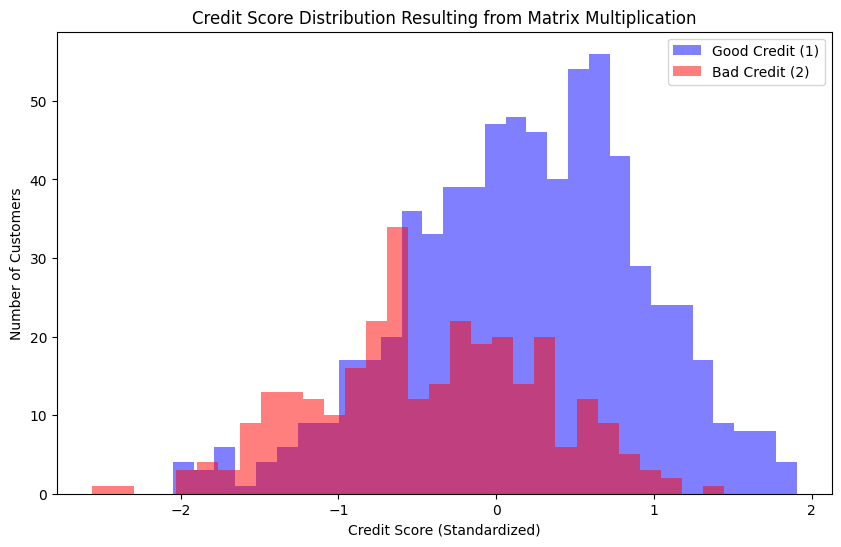

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/credit_final_cleaned.csv')

# 1. Pilih Fitur dan Target
X = df.drop('credit_risk', axis=1).values # Matriks Fitur (1000x6)
y = df['credit_risk'].values             # Target

# 2. Normalisasi (Agar semua fitur setara di mata Aljabar)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

# Menentukan bobot manual untuk 6 fitur:
# [checking, duration, history, purpose, amount, age]
w_expert = np.array([
    [0.4],  # Checking status (Sangat penting)
    [-0.5], # Duration (Makin lama makin berisiko, maka negatif)
    [0.3],  # Credit history
    [0.1],  # Purpose
    [-0.2], # Amount (Makin besar makin berat, maka negatif)
    [0.2]   # Age
])

# 3. MATRIX MULTIPLICATION (The Heart of AI)
# Menghitung skor kredit untuk 1000 orang sekaligus dalam satu kedipan mata
credit_scores = np.dot(X_std, w_expert)

# 4. IMPLEMENTASI MATRIX DIAGONAL (The Operator)
# Misal: Kita ingin memberi "Insentif" pada kolom Age (fitur ke-6)
# agar bobotnya lebih ringan 20% (0.8) karena data menunjukkan nasabah tua lebih stabil.
# Dan kita beri "Penalti" pada Duration (fitur ke-2) sebesar 1.5x.

# Membuat Matriks Diagonal (6x6)
# [checking, duration, history, purpose, amount, age]
d_operator = np.diag([1.0, 1.5, 1.0, 1.0, 1.0, 0.8])

# Operasi: Mengubah Bobot Expert menggunakan Matrix Diagonal
w_adjusted = np.dot(d_operator, w_expert)

# Hitung ulang skor dengan bobot yang sudah di-adjust
scores_final = np.dot(X_std, w_adjusted)

# 5. MENGUKUR MAGNITUDO (Frobenius Norm)
# Kita ingin tahu seberapa "berat" total risiko dari 1000 nasabah ini
total_risk_magnitude = np.linalg.norm(scores_final)

print(f"Magnitudo Risiko Portofolio (Frobenius): {total_risk_magnitude:.2f}")
print("5 Skor Nasabah Pertama:\n", scores_final[:35])

# 6. KEPUTUSAN BISNIS (Thresholding)
# Jika skor > 0, maka 'Good' (1), jika < 0 maka 'Bad' (2)
predictions = np.where(scores_final > 0, 1, 2)

# # Simpan skor ke dataframe untuk visualisasi
df['expert_score'] = credit_scores

plt.figure(figsize=(10, 6))

# # Plot distribusi untuk Good Credit
plt.hist(df[df['credit_risk'] == 1]['expert_score'], bins=30, alpha=0.5, label='Good Credit (1)', color='blue')

# # Plot distribusi untuk Bad Credit
plt.hist(df[df['credit_risk'] == 2]['expert_score'], bins=30, alpha=0.5, label='Bad Credit (2)', color='red')

plt.title('Credit Score Distribution Resulting from Matrix Multiplication')
plt.xlabel('Credit Score (Standardized)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

--- ANALISIS PORTOFOLIO KREDIT ---
Magnitudo Risiko Portofolio (Frobenius): 30.15
Jumlah nasabah di wilayah abu-abu (-0.2 s/d 0.2): 172

Samples Nasabah di Wilayah Abu-abu:
    final_score  credit_risk
4     -0.125209            2
10     0.141094            2
12     0.109500            1
13     0.119388            2
18     0.061917            2
19    -0.063677            1
27     0.009621            1
32    -0.125647            1
41    -0.101663            1
47    -0.081655            1


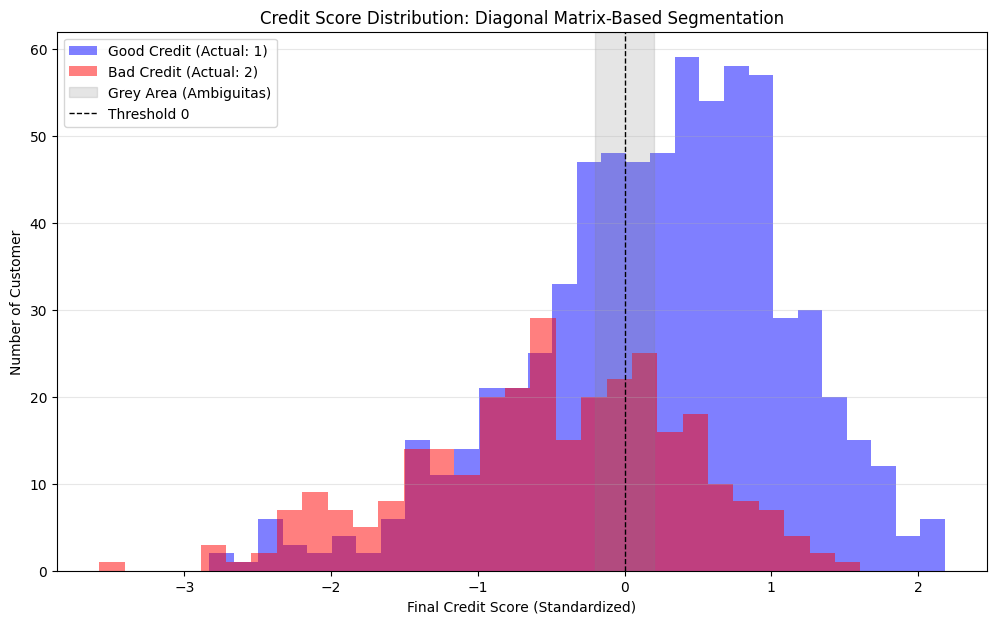

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/credit_final_cleaned.csv')

# 1. PENGELOLAAN MATRIKS (Aljabar Linear Dasar)
X = df.drop('credit_risk', axis=1).values
y = df['credit_risk'].values

# 2. NORMALISASI (Z-Score Standardization)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

# 3. INITIAL WEIGHTS (Expert Judgement)
w_expert = np.array([[0.4], [-0.5], [0.3], [0.1], [-0.2], [0.2]])

# 4. IMPLEMENTASI MATRIX DIAGONAL (Strategic Operator)
# Penyesuaian kebijakan: Penalti durasi (1.5x) & Insentif usia (0.8x)
d_operator = np.diag([1.0, 1.5, 1.0, 1.0, 1.0, 0.8])
w_adjusted = np.dot(d_operator, w_expert)

# 5. MATRIX MULTIPLICATION (Execution)
# Menghasilkan skor final untuk 1000 nasabah
scores_final = np.dot(X_std, w_adjusted)

# Masukkan skor final kembali ke DataFrame untuk analisis
df['final_score'] = scores_final

# 6. PENGUKURAN MAGNITUDO (Frobenius Norm)
total_risk_magnitude = np.linalg.norm(scores_final)

# 7. ANALISIS GREY AREA (Wilayah Ambang Batas)
# Mendefinisikan nasabah dengan skor mendekati threshold 0
grey_area_df = df[(df['final_score'] >= -0.2) & (df['final_score'] <= 0.2)]

# --- OUTPUT REPORT ---
print(f"--- ANALISIS PORTOFOLIO KREDIT ---")
print(f"Magnitudo Risiko Portofolio (Frobenius): {total_risk_magnitude:.2f}")
print(f"Jumlah nasabah di wilayah abu-abu (-0.2 s/d 0.2): {len(grey_area_df)}")
print("\nSamples Nasabah di Wilayah Abu-abu:")
print(grey_area_df[['final_score', 'credit_risk']].head(10))

# 8. VISUALISASI DISTRIBUSI
plt.figure(figsize=(12, 7))
plt.hist(df[df['credit_risk'] == 1]['final_score'], bins=30, alpha=0.5, label='Good Credit (Actual: 1)', color='blue')
plt.hist(df[df['credit_risk'] == 2]['final_score'], bins=30, alpha=0.5, label='Bad Credit (Actual: 2)', color='red')

# Tambahkan garis bantu untuk Grey Area
plt.axvspan(-0.2, 0.2, color='gray', alpha=0.2, label='Grey Area (Ambiguitas)')
plt.axvline(0, color='black', linestyle='--', linewidth=1, label='Threshold 0')

plt.title('Credit Score Distribution: Diagonal Matrix-Based Segmentation')
plt.xlabel('Final Credit Score (Standardized)')
plt.ylabel('Number of Customer')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()